## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv("bigmart.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


## Basic Statistics

In [4]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Handle Missing Values

In [5]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [7]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

## Select Features for Clustering

In [8]:
data = df[['Item_Weight','Item_MRP','Item_Outlet_Sales']]

## Feature Scaling

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
scaled_df.head()

,Item_Weight,Item_MRP,Item_Outlet_Sales
0,-0.841872,1.747454,0.910601
1,-1.641706,-1.489023,-1.018440
2,1.098554,0.010040,-0.049238
3,1.500838,0.660050,-0.849103
4,-0.929428,-1.399220,-0.695373


## Create Dendrogram

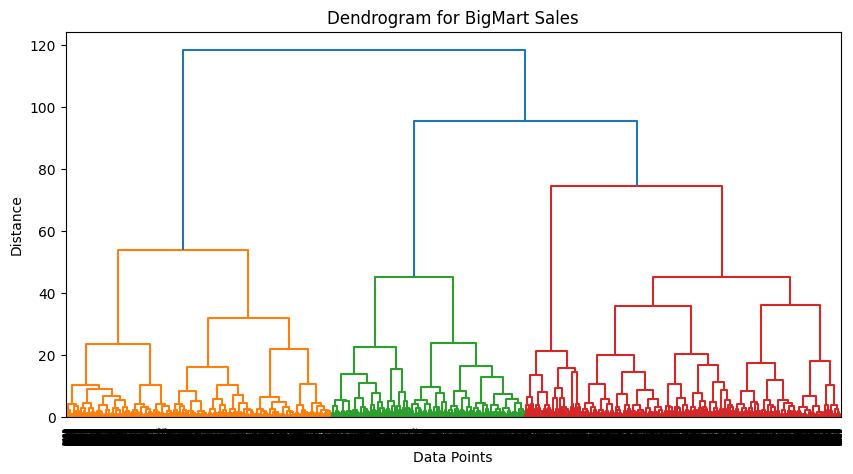

In [10]:
linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram for BigMart Sales")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## Agglomerative Clustering

In [11]:
model = AgglomerativeClustering(n_clusters=3)
clusters = model.fit_predict(scaled_df)
df['Cluster'] = clusters

## View Clustered Data

In [12]:
df[['Item_MRP','Item_Outlet_Sales','Cluster']].head()

,Item_MRP,Item_Outlet_Sales,Cluster
0,249.8092,3735.1380,0
1,48.2692,443.4228,1
2,141.6180,2097.2700,2
3,182.0950,732.3800,2
4,53.8614,994.7052,1


## Visualize Clusters

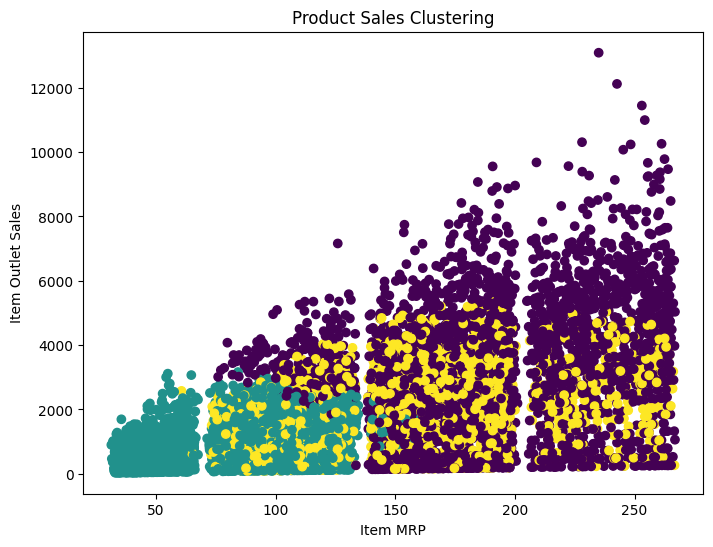

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], c=df['Cluster'])
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.title("Product Sales Clustering")
plt.show()

## Cluster Analysis

In [14]:
df.groupby('Cluster')[['Item_MRP','Item_Outlet_Sales']].mean()

,Item_MRP,Item_Outlet_Sales
Cluster,,
0,186.378854,3199.806578
1,78.127512,1033.343915
2,153.390318,2098.873106
